# market prediction

In [1]:
from data_utils import get_csv_list, batch_load, normalise_to_day_one
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


market_df = batch_load(
    get_csv_list("./data"), 
    pd_df=True, 
    # normalise=True,
)
stock_names = market_df.columns
sp500_idx = stock_names.get_loc("sp500")
print(stock_names)
market_database = market_df.to_numpy().transpose()
market_database = np.flip(market_database, axis=-1)
print(market_database)
norm_market_database = normalise_to_day_one(market_database)
print(norm_market_database)

Index(['v', 'bac', 'amc', 'intc', 'nvda', 'jpm', 'googl', 'jd', 'sp500', 'bmy',
       'lloy.l'],
      dtype='object')
[[5.25000e+01 5.32500e+01 5.36300e+01 ... 3.51830e+02 3.59140e+02
  3.55520e+02]
 [1.47100e+01 1.50000e+01 1.52700e+01 ... 4.17300e+01 4.33200e+01
  4.34200e+01]
 [2.24600e+02 2.31100e+02 2.31800e+02 ... 2.73000e+00 2.79000e+00
  2.75000e+00]
 ...
 [1.88819e+03 1.89332e+03 1.90201e+03 ... 5.66360e+03 5.67965e+03
  5.80720e+03]
 [4.88200e+01 4.88900e+01 4.88900e+01 ... 4.69000e+01 4.62000e+01
  4.73000e+01]
 [7.57300e+01 7.49900e+01 7.49000e+01 ... 7.78600e+01 7.83800e+01
  7.84200e+01]]
[[1.         1.01428571 1.02152381 ... 6.70152381 6.8407619  6.77180952]
 [1.         1.01971448 1.03806934 ... 2.83684568 2.94493542 2.95173351]
 [1.         1.02894034 1.03205699 ... 0.01215494 0.01242208 0.01224399]
 ...
 [1.         1.00271689 1.00731918 ... 2.99948628 3.00798648 3.07553795]
 [1.         1.00143384 1.00143384 ... 0.96067186 0.94633347 0.96886522]
 [1.         0.990

perfect performance with chance 0.3 = 485.2140217228432
average return = 26.63836674221118
sp500 return = 3.075537949041145
best stock performance = 265.15217391304344


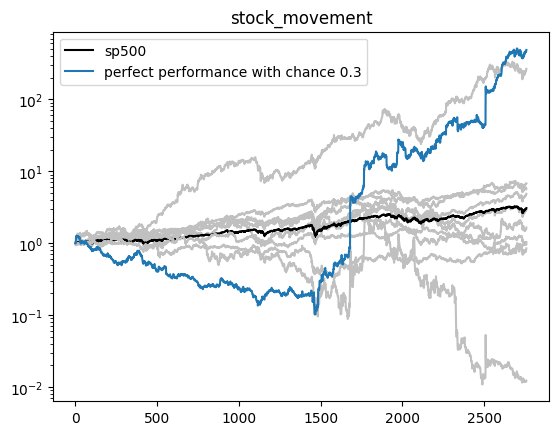

In [2]:
from data_utils import perfect_prediction, calculate_performance, plot_performance

optimal_chance = 0.3

perfect_pred = perfect_prediction(market_database, optimal_chance=optimal_chance)
perfect_performance = calculate_performance(market_database, perfect_pred, transaction_cost=1)

print(f"perfect performance with chance {optimal_chance} = {perfect_performance[-1]}")

plot_performance(
    norm_market_database, 
    {f"perfect performance with chance {optimal_chance}" : perfect_performance},
    sp500_idx  
)



In [3]:
import torch
from models import MLP_predictor, stock_train_test_split

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

train_data, test_data = stock_train_test_split(market_database)

print("train data", train_data)
print("test data", test_data)


train data [[  52.5    53.25   53.63 ...  220.73  220.    219.46]
 [  14.71   15.     15.27 ...   34.45   34.35   34.15]
 [ 224.6   231.1   231.8  ...   63.1    77.8    68.  ]
 ...
 [1888.19 1893.32 1902.01 ... 3973.24 3992.36 3977.19]
 [  48.82   48.89   48.89 ...   70.29   69.8    68.7 ]
 [  75.73   74.99   74.9  ...   47.44   48.28   46.85]]
test data [[2.17890e+02 2.20200e+02 2.23930e+02 ... 3.51830e+02 3.59140e+02
  3.55520e+02]
 [3.36600e+01 3.36500e+01 3.42400e+01 ... 4.17300e+01 4.33200e+01
  4.34200e+01]
 [6.24000e+01 6.20000e+01 6.58000e+01 ... 2.73000e+00 2.79000e+00
  2.75000e+00]
 ...
 [3.96334e+03 3.93868e+03 3.99802e+03 ... 5.66360e+03 5.67965e+03
  5.80720e+03]
 [6.92300e+01 6.93600e+01 6.93700e+01 ... 4.69000e+01 4.62000e+01
  4.73000e+01]
 [4.78100e+01 4.48100e+01 4.66500e+01 ... 7.78600e+01 7.83800e+01
  7.84200e+01]]


In [15]:
import torch
_a = torch.Tensor([0.9, -1, 2, 2])
_a[_a>0] = 1
_a[_a<=0] = 0
print(_a)

_b = torch.Tensor([1, 0, 1, 1])

print(torch.nn.functional.binary_cross_entropy(_a, _b))

tensor([1., 0., 1., 1.])
tensor(0.)


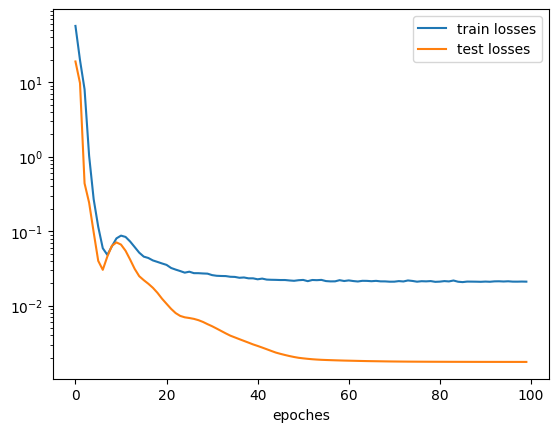

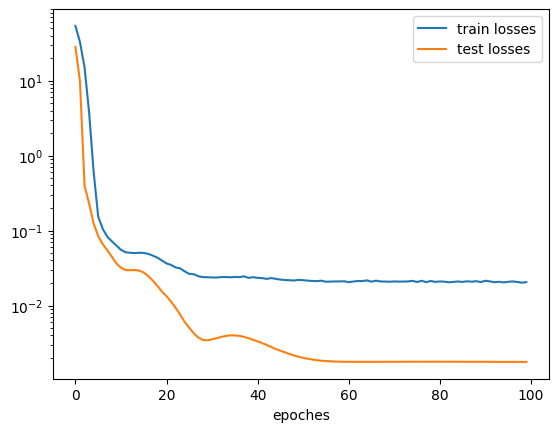

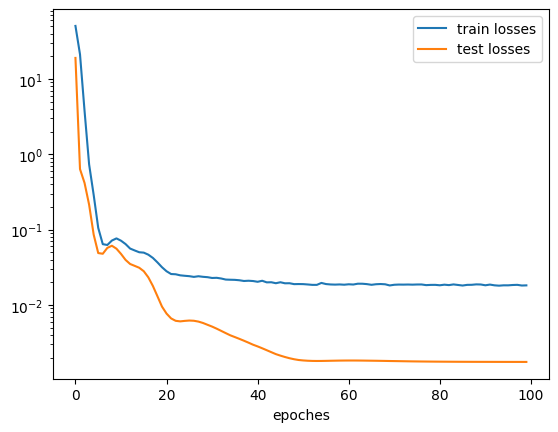

[9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9
 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9
 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 0 9 9 9 9 9 9 9 9 9 9 9 9 9
 9 9 9 9 9 9 9 9 9 9 9 9 9 9 6 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9
 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9
 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9
 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9
 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9
 9 9 9 9 9 0 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9
 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9
 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9
 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 6 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9
 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9
 9 9 9 9 9 9 9 9 9 9 9 9 

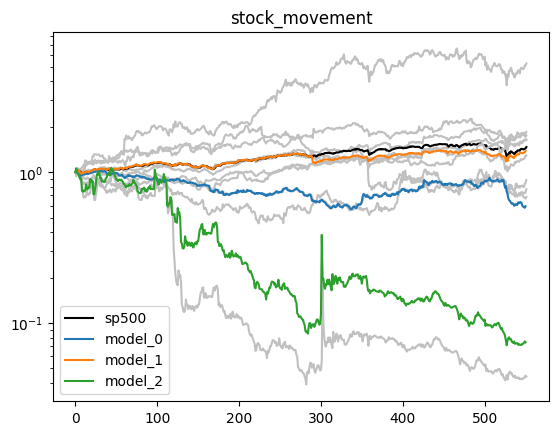

In [5]:
from data_utils import daily_changes, normalise_to_day_one
from models import mse_ce_loss_fn, train

train_set = daily_changes(train_data)
test_set = daily_changes(test_data)

num_stocks = train_set.shape[0]
num_models = 3
models = []


for i in range(num_models):
    model = MLP_predictor(number_stocks=num_stocks, num_hidden_layers=3, hidden_dim=64)
    train(
        model=model, 
        train_data=train_set, 
        test_data=test_set, 
        device=device, 
        print_log=True,
        loss_fn=mse_ce_loss_fn
    )
    models.append(model)

model_performance = {}

def model_predictions(model, test_set, print_log=False, device="cpu"):
    test_set = torch.tensor(test_set).transpose(1, 0).to(device)
    model.to(device)
    model.eval()
    prediction = model(test_set)
    pred = prediction.detach().cpu().numpy()

    pred_stock = np.argmax(daily_changes(pred), axis=-1)
    
    truth = test_set.detach().cpu().numpy()
    truth_market = np.argmax(truth, axis=-1)
    if print_log:
        print(pred)
        print(truth)
    return pred_stock, truth_market, pred, truth


for i in range(len(models)):
    model_pred, true_market, pred, truth = model_predictions(models[i], test_set[:, :-1], device=device)
    print(model_pred)
    model_performance[f"model_{i}"] = calculate_performance(test_data[:, 1:], model_pred)


print(true_market)


plot_performance(
    normalise_to_day_one(test_data), 
    model_performance,
    sp500_idx  
)

In [10]:
import torch
from torchinfo import summary
from models import SeqAnalyser

model = SeqAnalyser(10, 20)
print(summary(model, (4, 10, 20)))

Layer (type:depth-idx)                        Output Shape              Param #
SeqAnalyser                                   [4, 10]                   --
├─ParametrizedLinear: 1-1                     [4, 10, 64]               64
│    └─ModuleDict: 2-1                        --                        --
│    │    └─ParametrizationList: 3-1          [64, 20]                  1,344
├─Tanh: 1-2                                   [4, 10, 64]               --
├─ParametrizedLinear: 1-3                     [4, 64, 128]              128
│    └─ModuleDict: 2-2                        --                        --
│    │    └─ParametrizationList: 3-2          [128, 10]                 1,408
├─Tanh: 1-4                                   [4, 64, 128]              --
├─ModuleList: 1-7                             --                        (recursive)
│    └─ParametrizedLinear: 2-3                [4, 64, 128]              128
│    │    └─ModuleDict: 3-3                   --                        16,512

In [9]:
import torch
from models import stock_train_test_split, supervised_train, StockDataset
from data_utils import batch_load, get_csv_list, daily_changes, normalise_to_day_one
from torch.utils.data import DataLoader
import numpy as np

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
time_window = 64
batch_size = 128
csv_folder = "./data"

market_df = batch_load(
    get_csv_list("./data"), 
    pd_df=True, 
    # normalise=True,
)
stock_names = market_df.columns
sp500_idx = stock_names.get_loc("sp500")
print(stock_names)
market_database = market_df.to_numpy().transpose()
market_database = np.flip(market_database, axis=-1)
train_data, test_data = stock_train_test_split(market_database)

train_set = StockDataset(daily_changes(train_data), time_window)
test_set = StockDataset(daily_changes(test_data), time_window)

train_dataloader = DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True
)

test_dataloader = DataLoader(
    test_set,
    batch_size=batch_size,
)

norm_test_market_data = normalise_to_day_one(test_data)
print(norm_test_market_data)

Index(['v', 'bac', 'amc', 'intc', 'nvda', 'jpm', 'googl', 'jd', 'sp500', 'bmy',
       'lloy.l'],
      dtype='object')
[[1.         1.01060167 1.02772038 ... 1.61471379 1.64826296 1.63164895]
 [1.         0.99970296 1.01723119 ... 1.23975044 1.28698752 1.28995836]
 [1.         0.99358972 1.0544872  ... 0.04375    0.04471154 0.04407051]
 ...
 [1.         0.99377794 1.00875018 ... 1.42899675 1.43304631 1.46522884]
 [1.         1.00187776 1.00202224 ... 0.67745196 0.66734073 0.68322977]
 [1.         0.93725162 0.9757373  ... 1.62852956 1.63940588 1.64024254]]


train loss for epoch 0 = 5.615098476409912
test loss for epoch 0 = 0.08459160476922989
train loss for epoch 1 = 0.07690178602933884
test loss for epoch 1 = 0.02978929877281189
train loss for epoch 2 = 0.0621662363409996
test loss for epoch 2 = 0.030203107744455338
train loss for epoch 3 = 0.01467400137335062
test loss for epoch 3 = 0.006876060273498297
train loss for epoch 4 = 0.00756822619587183
test loss for epoch 4 = 0.01125811506062746
train loss for epoch 5 = 0.005380198825150728
test loss for epoch 5 = 0.004939788952469826
train loss for epoch 6 = 0.0030138150323182344
test loss for epoch 6 = 0.00292465859092772
train loss for epoch 7 = 0.0026011806912720203
test loss for epoch 7 = 0.0025911019183695316
train loss for epoch 8 = 0.00235833995975554
test loss for epoch 8 = 0.002631237031891942
train loss for epoch 9 = 0.0023535038344562054
test loss for epoch 9 = 0.0026871664449572563
train loss for epoch 10 = 0.0023301749024540186
test loss for epoch 10 = 0.0027182702906429768
tra

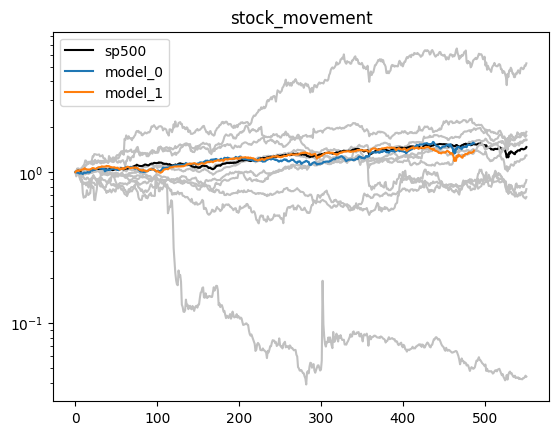

In [17]:
from models import model_predictions_using_test_dataloader, SeqAnalyser, mse_ce_loss_fn
from data_utils import calculate_performance, plot_performance


num_stocks = train_data.shape[0]
num_models = 2
models = []

for i in range(num_models):
    model = SeqAnalyser(
        num_stocks,
        time_window,
        time_feature_dim=16,
        stock_feature_dim=64,
        num_stock_layer=2,
    )
    supervised_train(
        model, 
        train_dataloader, 
        test_dataloader, 
        device=device, 
        epochs=50,
        print_log=True,
        scheduler_gamma=0.9,
        optimizer_lr=1e-3,
        loss_fn=mse_ce_loss_fn
    )
    models.append(model)

model_performance = {}

for i in range(len(models)):
    model_pred, true_market = model_predictions_using_test_dataloader(models[i], test_dataloader, device=device)
    print(model_pred)
    model_performance[f"model_{i}"] = calculate_performance(test_data[:, time_window:], model_pred)

print(true_market)

plot_performance(
    norm_test_market_data, 
    model_performance,
    sp500_idx  
)